# 🧊 Atoti DataMart & OLAP - Crypto Data Warehouse
**Team 4 INT24 | Data Warehouse Final Project 2025/2026**

This notebook builds a DataMart using **Atoti** from the data loaded into Supabase.

### 5 Analytical Targets:
1. Volatility profile per asset & time period
2. Sentiment vs price movement correlation
3. Trend distribution across time hierarchy
4. Volume anomaly & price impact
5. RSI momentum & trend reversal patterns

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'pyarrow', 'python-dotenv'], check=True)

CompletedProcess(args=['pip', 'install', 'pyarrow', 'python-dotenv'], returncode=0)

In [2]:

import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('../.env'))

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_KEY')
PROCESSED    = Path('../data/processed')

print('Environment loaded')
print(f'   SUPABASE_URL = {SUPABASE_URL[:40]}...' if SUPABASE_URL else '   SUPABASE_URL not found')

Environment loaded
   SUPABASE_URL = https://zynmpfvpgrfyqgofuylb.supabase.co...


In [3]:

def load_from_supabase(table: str) -> pd.DataFrame:
    """Load table dari Supabase via REST API."""
    import requests
    headers = {
        'apikey': SUPABASE_KEY,
        'Authorization': f'Bearer {SUPABASE_KEY}',
    }
    all_rows = []
    limit = 1000
    offset = 0
    while True:
        url = f'{SUPABASE_URL}/rest/v1/{table}?select=*&limit={limit}&offset={offset}'
        resp = requests.get(url, headers=headers, timeout=30)
        resp.raise_for_status()
        rows = resp.json()
        all_rows.extend(rows)
        if len(rows) < limit:
            break
        offset += limit
    print(f'   Loaded {table}: {len(all_rows):,} rows')
    return pd.DataFrame(all_rows)

def load_latest_parquet(prefix: str) -> pd.DataFrame:
    files = sorted(PROCESSED.glob(f'{prefix}_*.parquet'))
    if not files:
        files = sorted(PROCESSED.glob(f'{prefix}_*.csv'))
        return pd.read_csv(files[-1])
    return pd.read_parquet(files[-1])

print('Loading data...')
try:
    fact_daily   = load_from_supabase('fact_market_daily')
    fact_hourly  = load_from_supabase('fact_market_hourly')
    dim_time     = load_from_supabase('dim_time')
    dim_asset    = load_from_supabase('dim_asset')
    dim_sentiment= load_from_supabase('dim_sentiment')
    dim_trend    = load_from_supabase('dim_trend')
    source = 'Supabase'
except Exception as e:
    print(f' Supabase connection failed ({e}), falling back to local Parquet...')
    fact_daily   = load_latest_parquet('fact_market_daily')
    fact_hourly  = load_latest_parquet('fact_market_hourly')
    dim_time     = load_latest_parquet('dim_time')
    dim_asset    = load_latest_parquet('dim_asset')
    dim_sentiment= load_latest_parquet('dim_sentiment')
    dim_trend    = load_latest_parquet('dim_trend')
    source = 'lokal (parquet)'

print(f'\n Data loaded from: {source}')
print(f'   fact_market_daily : {len(fact_daily):,} rows')

Loading data...
   Loaded fact_market_daily: 3,645 rows
   Loaded fact_market_hourly: 87,308 rows
   Loaded dim_time: 731 rows
   Loaded dim_asset: 5 rows
   Loaded dim_sentiment: 5 rows
   Loaded dim_trend: 7 rows

 Data loaded dari: Supabase
   fact_market_daily : 3,645 rows


In [4]:

df = fact_daily.copy()

df = df.merge(dim_time[['date_key','date','year','quarter','month','week','day_of_week','day_name','is_weekend']],
              on='date_key', how='left')
df = df.merge(dim_asset[['asset_key','symbol','name','category']], on='asset_key', how='left')
df = df.merge(dim_sentiment[['sentiment_key','fng_classification','fng_label']], on='sentiment_key', how='left')
df = df.merge(dim_trend[['trend_key','trend_label','rsi_signal']], on='trend_key', how='left')

df['date']         = pd.to_datetime(df['date'])
df['year']         = df['year'].astype(str)
df['quarter']      = 'Q' + df['quarter'].astype(str)
df['month']        = df['month'].astype(int)
df['week']         = df['week'].astype(int)

numeric_cols = ['open','high','low','close','volume','fng_value',
                'daily_return','ma7','ma30','volatility_7d','rsi_14','volume_zscore']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f' Denormalized DataFrame shape: {df.shape}')
print(f'   Kolom: {list(df.columns)}')
df.head(3)

 Denormalized DataFrame shape: (3645, 33)
   Kolom: ['fact_key', 'date_key', 'asset_key', 'sentiment_key', 'trend_key', 'open', 'high', 'low', 'close', 'volume', 'fng_value', 'daily_return', 'ma7', 'ma30', 'volatility_7d', 'rsi_14', 'volume_zscore', 'is_volume_anomaly', 'date', 'year', 'quarter', 'month', 'week', 'day_of_week', 'day_name', 'is_weekend', 'symbol', 'name', 'category', 'fng_classification', 'fng_label', 'trend_label', 'rsi_signal']


,fact_key,date_key,asset_key,sentiment_key,trend_key,open,high,low,close,volume,...,day_of_week,day_name,is_weekend,symbol,name,category,fng_classification,fng_label,trend_label,rsi_signal
0,597,20260106,5,2.0,4,0.421845,0.435673,0.401939,0.419619,161674048.0,...,1,Tuesday,False,ADA-USD,Cardano,Cryptocurrency,fear,Fear,bullish,neutral
1,598,20260107,5,2.0,4,0.419392,0.421513,0.398722,0.401897,36821120.0,...,2,Wednesday,False,ADA-USD,Cardano,Cryptocurrency,fear,Fear,bullish,neutral
2,599,20260108,5,2.0,4,0.401899,0.403747,0.385887,0.395645,128379776.0,...,3,Thursday,False,ADA-USD,Cardano,Cryptocurrency,fear,Fear,bullish,neutral


In [5]:
import atoti as tt

session = tt.Session.start()
print(f' Atoti session started: {session.url}')

Welcome to Atoti 0.9.14!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.
 Atoti session started: http://localhost:61755


In [6]:

store = session.read_pandas(
    df,
    table_name='crypto_market',
    keys=['fact_key']
)

cube = session.create_cube(store, name='Crypto DWH Cube')

print('  Cube created')
print('   Available Measures:', list(cube.measures.keys())[:10], '...')
print('   Available Hierarchies:', list(cube.hierarchies.keys()))

  Cube dibuat
   Measures tersedia: ['asset_key.MEAN', 'asset_key.SUM', 'close.MEAN', 'close.SUM', 'contributors.COUNT', 'daily_return.MEAN', 'daily_return.SUM', 'date_key.MEAN', 'date_key.SUM', 'day_of_week.MEAN'] ...
   Hierarchies tersedia: [('crypto_market', 'is_weekend'), ('crypto_market', 'fng_label'), ('crypto_market', 'fact_key'), ('crypto_market', 'rsi_signal'), ('crypto_market', 'fng_classification'), ('crypto_market', 'date'), ('crypto_market', 'trend_label'), ('crypto_market', 'symbol'), ('crypto_market', 'category'), ('crypto_market', 'is_volume_anomaly'), ('crypto_market', 'day_name'), ('crypto_market', 'name'), ('crypto_market', 'quarter'), ('crypto_market', 'year')]


In [9]:
m, h = cube.measures, cube.hierarchies

m['Avg Close']         = tt.agg.mean(store['close'])
m['Avg Daily Return']  = tt.agg.mean(store['daily_return'])
m['Avg Volatility 7d'] = tt.agg.mean(store['volatility_7d'])
m['Avg RSI 14']        = tt.agg.mean(store['rsi_14'])
m['Total Volume']      = tt.agg.sum(store['volume'])
m['Avg FnG Score']     = tt.agg.mean(store['fng_value'])
m['Max Daily Return']  = tt.agg.max(store['daily_return'])
m['Min Daily Return']  = tt.agg.min(store['daily_return'])
m['Volatility Max']    = tt.agg.max(store['volatility_7d'])

print(' Custom measures created')

 Custom measures created


## Analytical Target 1 - Volatility Profile per Asset & Time

In [10]:
print('=== T1: Avg Volatility 7d - per Quarter per Asset ===')
result_t1 = cube.query(
    m['Avg Volatility 7d'],
    m['Avg Daily Return'],
    levels=[h['symbol']['symbol'], h['quarter']['quarter']]
)
result_t1

=== T1: Avg Volatility 7d — per Quarter per Asset ===


Avg Volatility 7d Avg Daily Return
symbol  quarter                                   
ADA-USD Q1                    .05             -.00
        Q2                    .03             -.00
        Q3                    .03              .00
        Q4                    .05              .00
BNB-USD Q1                    .03             -.00
        Q2                    .02              .00
        Q3                    .02              .00
        Q4                    .03              .00
BTC-USD Q1                    .03             -.00
        Q2                    .02              .00
        Q3                    .02              .00
        Q4                    .02              .00
ETH-USD Q1                    .04             -.00
        Q2                    .03              .00
        Q3                    .03              .00
        Q4                    .03              .00
SOL-USD Q1                    .04             -.00
        Q2                    .03              .00
        Q3                    .04              .00
        Q4                    .04             -.00

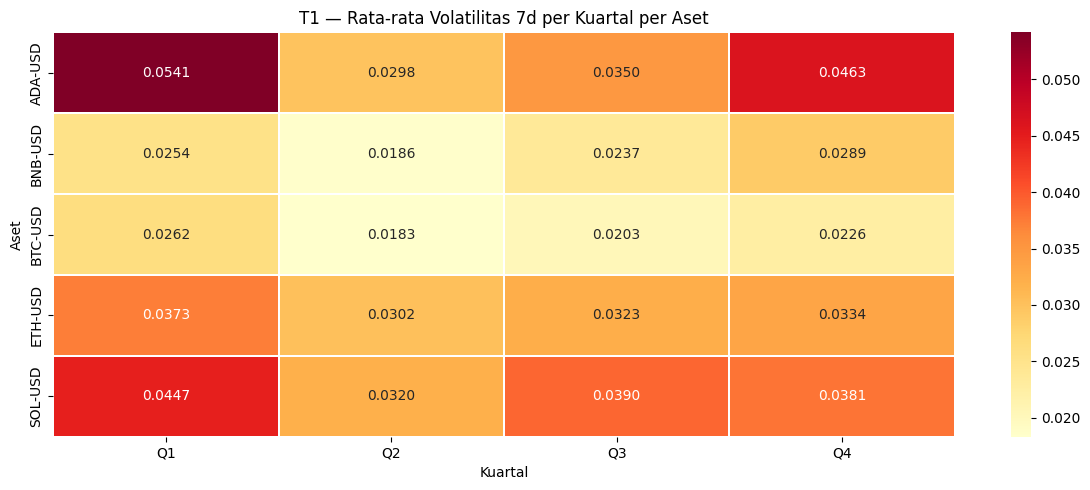

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

vol_pivot = result_t1['Avg Volatility 7d'].unstack('symbol')
vol_pivot = vol_pivot.astype(float)  

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(vol_pivot.T, cmap='YlOrRd', annot=True, fmt='.4f', linewidths=0.3, ax=ax)
ax.set_title('T1 — Rata-rata Volatilitas 7d per Kuartal per Asset')
ax.set_xlabel('Kuartal')
ax.set_ylabel('Asset')
plt.tight_layout()
plt.show()

## Analytical Target 2 — Sentiment vs Price Movement

In [13]:
print('=== T2: Avg Daily Return per Sentiment Label per Asset ===')
result_t2 = cube.query(
    m['Avg Daily Return'],
    m['Avg FnG Score'],
    m['Avg Volatility 7d'],
    levels=[h['fng_label']['fng_label'], h['symbol']['symbol']]
)
result_t2

=== T2: Avg Daily Return per Sentiment Label per Asset ===


Avg Daily Return Avg FnG Score Avg Volatility 7d
fng_label     symbol                                                  
Extreme Fear  ADA-USD              .00         15.80               .05
              BNB-USD              .00         15.80               .03
              BTC-USD              .00         15.80               .03
              ETH-USD              .00         15.80               .04
              SOL-USD              .00         15.80               .04
Extreme Greed ADA-USD              .01         79.15               .05
              BNB-USD             -.00         79.15               .03
              BTC-USD             -.00         79.15               .02
              ETH-USD             -.00         79.15               .04
              SOL-USD             -.00         79.15               .04
Fear          ADA-USD             -.00         35.84               .04
              BNB-USD              .00         35.84               .03
              BTC-USD             -.00         35.84               .02
              ETH-USD             -.00         35.84               .03
              SOL-USD             -.00         35.84               .04
Greed         ADA-USD             -.00         68.01               .03
              BNB-USD              .00         68.01               .02
              BTC-USD              .00         68.01               .02
              ETH-USD              .00         68.01               .03
              SOL-USD              .00         68.01               .03
N/A           ADA-USD              .03                             .04
              BNB-USD              .01                             .02
              BTC-USD              .01                             .02
              ETH-USD              .02                             .03
              SOL-USD              .04                             .04
Neutral       ADA-USD              .00         51.60               .03
              BNB-USD              .00         51.60               .02
              BTC-USD              .00         51.60               .02
              ETH-USD              .00         51.60               .03
              SOL-USD             -.00         51.60               .03

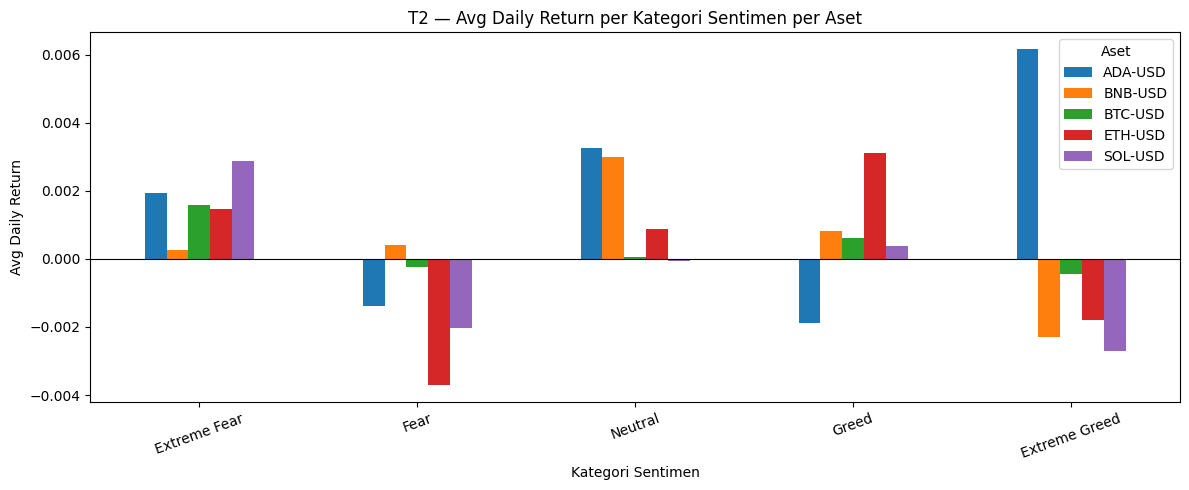

In [14]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

try:
    ret_pivot = result_t2['Avg Daily Return'].unstack('symbol')
    ret_pivot = ret_pivot.reindex([s for s in sentiment_order if s in ret_pivot.index])

    fig, ax = plt.subplots(figsize=(12, 5))
    ret_pivot.plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('T2 — Avg Daily Return per Sentiment Category per Asset')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Avg Daily Return')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
    ax.legend(title='Asset')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e} — cek struktur index result_t2')

##  Analytical Target 3 — Trend Distribution Across Time

In [17]:
print('=== T3: Trend Distribution per Quarter per Asset ===')
result_t3 = cube.query(
    m['contributors.COUNT'],
    levels=[
        h['symbol']['symbol'],
        h['trend_label']['trend_label'],
        h['year']['year'],
        h['quarter']['quarter']
    ]
)
result_t3.head(20)

=== T3: Trend Distribution per Quarter per Asset ===


contributors.COUNT
symbol  trend_label year quarter                    
ADA-USD bearish     2024 Q2                       35
                         Q3                       55
                         Q4                       45
                    2025 Q1                       63
                         Q2                       55
                         Q3                       37
                         Q4                       92
                    2026 Q1                       66
                         Q2                       25
        bullish     2024 Q3                       37
                         Q4                       47
                    2025 Q1                       27
                         Q2                       36
                         Q3                       55
                    2026 Q1                       24
                         Q2                       23
        neutral     2024 Q2                        7
BNB-USD bearish     2024 Q2                       23
                         Q3                       47
                         Q4                       25

In [18]:
result_t3_btc = cube.query(
    m['contributors.COUNT'],
    levels=[h['trend_label']['trend_label'], h['year']['year'], h['quarter']['quarter']],
    filter=h['symbol']['symbol'] == 'BTC-USD'
)
result_t3_btc

contributors.COUNT
trend_label year quarter                   
bearish     2024 Q2                      28
                 Q3                      52
                 Q4                      15
            2025 Q1                      64
                 Q2                      34
                 Q3                      37
                 Q4                      76
            2026 Q1                      48
                 Q2                       9
bullish     2024 Q2                       7
                 Q3                      40
                 Q4                      77
            2025 Q1                      26
                 Q2                      57
                 Q3                      55
                 Q4                      16
            2026 Q1                      42
                 Q2                      39
neutral     2024 Q2                       7

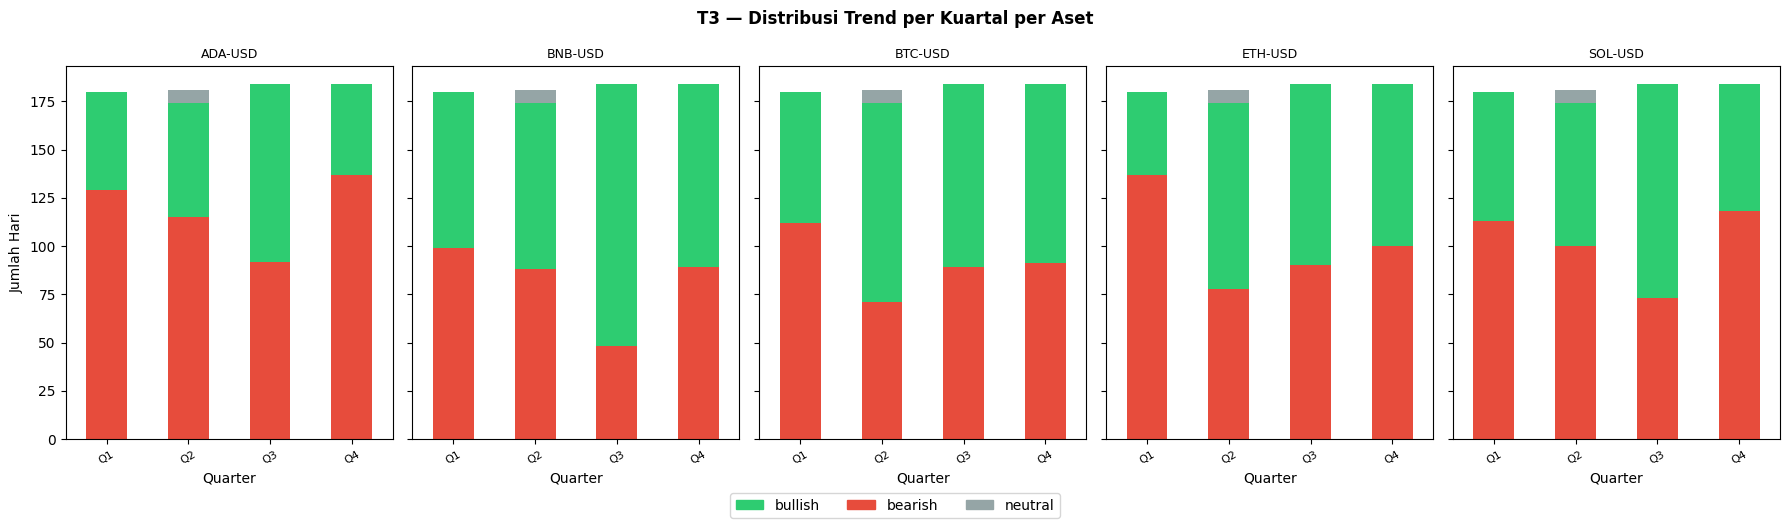

In [19]:
result_t3_q = cube.query(
    m['contributors.COUNT'],
    levels=[h['symbol']['symbol'], h['trend_label']['trend_label'], h['quarter']['quarter']]
)

try:
    df_t3 = result_t3_q.reset_index()
    pivot = df_t3.pivot_table(index=['symbol','quarter'], columns='trend_label',
                              values='contributors.COUNT', fill_value=0)

    fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
    symbols = df_t3['symbol'].unique()
    colors = {'bullish': '#2ecc71', 'bearish': '#e74c3c', 'neutral': '#95a5a6'}

    for ax, sym in zip(axes, symbols):
        sub = pivot.loc[sym] if sym in pivot.index.get_level_values(0) else pd.DataFrame()
        if len(sub) > 0:
            sub.plot(kind='bar', stacked=True, ax=ax,
                     color=[colors.get(c,'gray') for c in sub.columns])
        ax.set_title(sym, fontsize=9)
        ax.set_xlabel('Quarter')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, fontsize=8)
        ax.get_legend().remove() if ax.get_legend() else None

    axes[0].set_ylabel('Number of Days')
    fig.suptitle('T3 - Trend Distribution per Quarter per Asset', fontsize=12, fontweight='bold')
    handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
    fig.legend(handles, colors.keys(), loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

##  Analytical Target 4 — Volume Anomaly & Price Impact

In [21]:
print('=== T4: Volume & Return per Sentiment per Asset ===')
result_t4 = cube.query(
    m['Total Volume'],
    m['Avg Daily Return'],
    m['contributors.COUNT'],
    levels=[h['symbol']['symbol'], h['fng_label']['fng_label']]
)
result_t4

=== T4: Volume & Return per Sentiment per Asset ===


Total Volume Avg Daily Return  \
symbol  fng_label                                              
ADA-USD Extreme Fear      29,615,360,096.00              .00   
        Extreme Greed     55,676,693,696.00              .01   
        Fear              91,276,834,336.00             -.00   
        Greed             54,073,823,872.00             -.00   
        N/A                   48,779,104.00              .03   
        Neutral           13,930,545,824.00              .00   
BNB-USD Extreme Fear      64,192,991,040.00              .00   
        Extreme Greed     33,347,352,576.00             -.00   
        Fear              90,876,661,184.00              .00   
        Greed             74,550,547,712.00              .00   
        N/A                   71,738,112.00              .01   
        Neutral           21,638,299,136.00              .00   
BTC-USD Extreme Fear   2,016,350,784,512.00              .00   
        Extreme Greed  1,137,763,040,256.00             -.00   
        Fear           2,815,565,673,472.00             -.00   
        Greed          2,851,845,533,696.00              .00   
        N/A                1,675,874,304.00              .01   
        Neutral          636,711,502,848.00              .00   
ETH-USD Extreme Fear   1,143,473,399,808.00              .00   
        Extreme Greed    644,946,208,256.00             -.00   
        Fear           1,687,498,010,112.00             -.00   
        Greed          1,947,239,891,968.00              .00   
        N/A                1,645,645,824.00              .02   
        Neutral          488,841,659,392.00              .00   
SOL-USD Extreme Fear     195,032,462,336.00              .00   
        Extreme Greed    140,396,305,664.00             -.00   
        Fear             283,547,448,192.00             -.00   
        Greed            264,281,516,032.00              .00   
        N/A                  354,360,320.00              .04   
        Neutral           78,829,550,080.00             -.00   

                      contributors.COUNT  
symbol  fng_label                         
ADA-USD Extreme Fear                 144  
        Extreme Greed                 71  
        Fear                         238  
        Greed                        218  
        N/A                            1  
        Neutral                       57  
BNB-USD Extreme Fear                 144  
        Extreme Greed                 71  
        Fear                         238  
        Greed                        218  
        N/A                            1  
        Neutral                       57  
BTC-USD Extreme Fear                 144  
        Extreme Greed                 71  
        Fear                         238  
        Greed                        218  
        N/A                            1  
        Neutral                       57  
ETH-USD Extreme Fear                 144  
        Extreme Greed                 71  
        Fear                         238  
        Greed                        218  
        N/A                            1  
        Neutral                       57  
SOL-USD Extreme Fear                 144  
        Extreme Greed                 71  
        Fear                         238  
        Greed                        218  
        N/A                            1  
        Neutral                       57

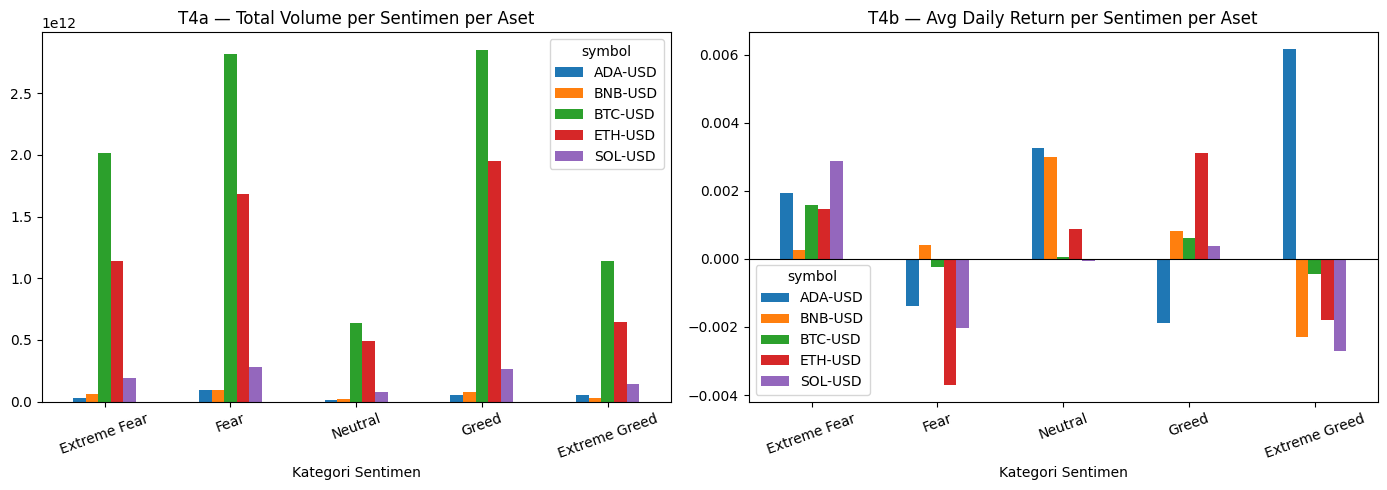

In [22]:
try:
    df_t4 = result_t4.reset_index()
    sentiment_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    vol_pivot = df_t4.pivot_table(index='fng_label', columns='symbol',
                                   values='Total Volume', aggfunc='sum')
    vol_pivot = vol_pivot.reindex([s for s in sentiment_order if s in vol_pivot.index])
    vol_pivot.plot(kind='bar', ax=axes[0])
    axes[0].set_title('T4a - Total Volume per Sentiment per Asset')
    axes[0].set_xlabel('Sentiment Category')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)

    ret_pivot = df_t4.pivot_table(index='fng_label', columns='symbol',
                                   values='Avg Daily Return', aggfunc='mean')
    ret_pivot = ret_pivot.reindex([s for s in sentiment_order if s in ret_pivot.index])
    ret_pivot.plot(kind='bar', ax=axes[1])
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('T4b - Avg Daily Return per Sentiment per Asset')
    axes[1].set_xlabel('Sentiment Category')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

## Analytical Target 5 — RSI Momentum & Trend Reversal

In [23]:
print('=== T5: RSI Signal Distribution per Trend per Asset ===')
result_t5 = cube.query(
    m['contributors.COUNT'],
    m['Avg RSI 14'],
    m['Avg Daily Return'],
    levels=[h['symbol']['symbol'], h['rsi_signal']['rsi_signal'], h['trend_label']['trend_label']]
)
result_t5

=== T5: RSI Signal Distribution per Trend per Asset ===


contributors.COUNT Avg RSI 14 Avg Daily Return
symbol  rsi_signal trend_label                                               
ADA-USD neutral    bearish                    429      43.17              .00
                   bullish                    205      53.62             -.01
                   neutral                      7                        -.01
        overbought bearish                      1      73.20              .72
                   bullish                     44      78.64              .04
        oversold   bearish                     43      25.50             -.03
BNB-USD neutral    bearish                    297      45.23              .00
                   bullish                    358      55.52             -.00
                   neutral                      7                        -.00
        overbought bearish                      1      88.56              .04
                   bullish                     40      77.61              .02
        oversold   bearish                     26      26.32             -.02
BTC-USD neutral    bearish                    327      44.32              .00
                   bullish                    318      56.88             -.00
                   neutral                      7                        -.01
        overbought bullish                     40      74.94              .02
        oversold   bearish                     36      25.68             -.02
                   bullish                      1      26.62             -.03
ETH-USD neutral    bearish                    381      43.23              .00
                   bullish                    268      56.02             -.00
                   neutral                      7                         .01
        overbought bearish                      1      82.57              .01
                   bullish                     49      77.13              .02
        oversold   bearish                     23      26.32             -.04
SOL-USD neutral    bearish                    363      42.97              .00
                   bullish                    288      55.99             -.00
                   neutral                      7                        -.02
        overbought bullish                     30      73.94              .03
        oversold   bearish                     41      24.20             -.02

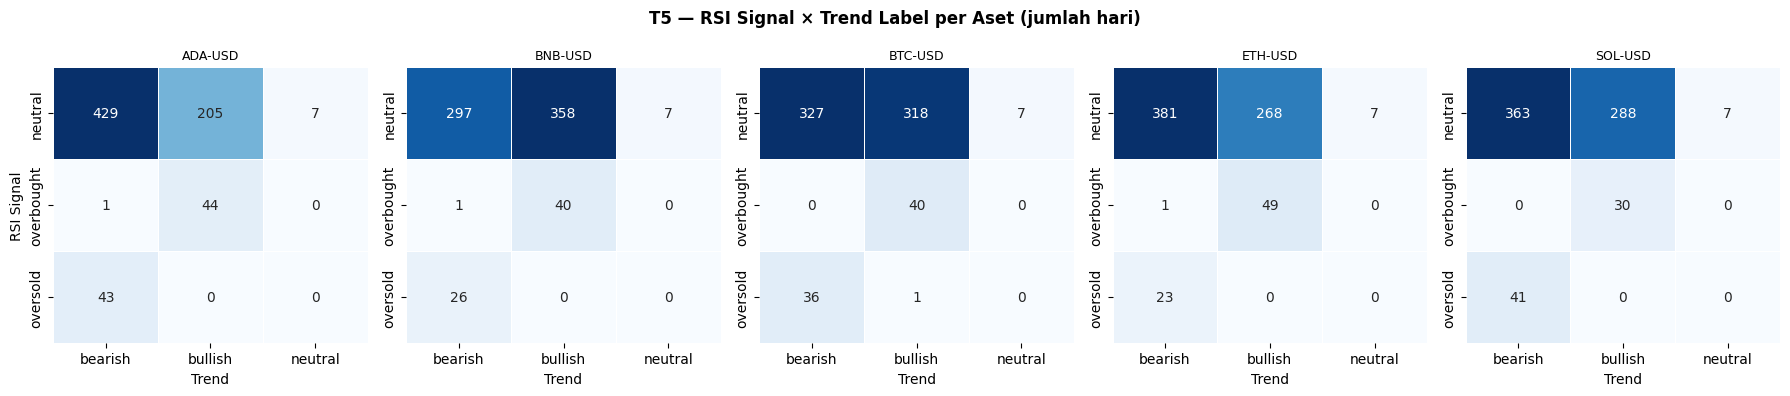

In [25]:
try:
    df_t5 = result_t5.reset_index()
    df_t5['contributors.COUNT'] = pd.to_numeric(df_t5['contributors.COUNT'], errors='coerce')
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    symbols = sorted(df_t5['symbol'].unique())
    
    for ax, sym in zip(axes, symbols):
        sub = df_t5[df_t5['symbol'] == sym]
        pivot = sub.pivot_table(index='rsi_signal', columns='trend_label',
                                values='contributors.COUNT', fill_value=0, aggfunc='sum')
        pivot = pivot.astype(float)  
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                    cbar=False, linewidths=0.5)
        ax.set_title(sym, fontsize=9)
        ax.set_xlabel('Trend')
        ax.set_ylabel('RSI Signal' if sym == symbols[0] else '')
    
    fig.suptitle('T5 - RSI Signal x Trend Label per Asset (Day Count)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualisasi error: {e}')

##  Atoti Widget (Interactive Dashboard)

In [26]:
widget_vol = cube.query(
    m['Avg Volatility 7d'],
    m['Avg Daily Return'],
    m['Avg RSI 14'],
    levels=[h['symbol']['symbol'], h['year']['year'], h['quarter']['quarter']]
)
print('=== Widget 1: Volatility Profile per Year-Quarter per Asset ===')
widget_vol

=== Widget 1: Volatility Profile per Year-Quarter per Asset ===


Avg Volatility 7d Avg Daily Return Avg RSI 14
symbol  year quarter                                              
ADA-USD 2024 Q2                    .02             -.01      26.51
             Q3                    .03              .00      47.93
             Q4                    .05              .01      58.59
        2025 Q1                    .07              .00      45.82
             Q2                    .04             -.00      46.64
             Q3                    .04              .00      55.41
             Q4                    .04             -.01      37.86
        2026 Q1                    .04             -.00      43.64
             Q2                    .03              .00      50.38
BNB-USD 2024 Q2                    .02             -.00      59.10
             Q3                    .03              .00      49.89
             Q4                    .03              .00      55.23
        2025 Q1                    .03             -.00      46.85
             Q2                    .02              .00      52.27
             Q3                    .02              .00      63.65
             Q4                    .03             -.00      46.51
        2026 Q1                    .02             -.00      43.79
             Q2                    .02              .00      51.81
BTC-USD 2024 Q2                    .01             -.00      28.49
             Q3                    .03              .00      48.97
             Q4                    .02              .00      61.83
        2025 Q1                    .03             -.00      46.92
             Q2                    .02              .00      57.93
             Q3                    .01              .00      53.62
             Q4                    .02             -.00      43.27
        2026 Q1                    .03             -.00      44.60
             Q2                    .02              .00      58.46
ETH-USD 2024 Q2                    .02             -.00      58.16
             Q3                    .03             -.00      44.19
             Q4                    .03              .00      55.91
        2025 Q1                    .04             -.01      40.48
             Q2                    .04              .00      53.90
             Q3                    .03              .01      61.04
             Q4                    .03             -.00      43.32
        2026 Q1                    .04             -.00      44.53
             Q2                    .02              .00      53.41
SOL-USD 2024 Q2                    .03             -.01      25.45
             Q3                    .04              .00      49.53
             Q4                    .04              .00      55.97
        2025 Q1                    .05             -.00      44.57
             Q2                    .04              .00      51.86
             Q3                    .04              .00      56.82
             Q4                    .04             -.00      41.33
        2026 Q1                    .04             -.00      44.47
             Q2                    .02              .00      51.04

In [27]:
widget_sent = cube.query(
    m['Avg Daily Return'],
    m['Avg Volatility 7d'],
    m['Avg FnG Score'],
    levels=[
        h['fng_label']['fng_label'],
        h['symbol']['symbol'],
        h['trend_label']['trend_label']
    ]
)
print('=== Widget 2: Sentiment x Asset x Trend ===')
widget_sent

=== Widget 2: Sentiment × Asset × Trend ===


Avg Daily Return Avg Volatility 7d  \
fng_label    symbol  trend_label                                      
Extreme Fear ADA-USD bearish                  .00               .04   
                     bullish                  .01               .10   
             BNB-USD bearish                 -.00               .03   
                     bullish                  .00               .02   
             BTC-USD bearish                  .00               .03   
...                                           ...               ...   
Neutral      BTC-USD bullish                  .00               .02   
             ETH-USD bearish                 -.00               .03   
                     bullish                  .00               .03   
             SOL-USD bearish                 -.01               .03   
                     bullish                  .01               .03   

                                 Avg FnG Score  
fng_label    symbol  trend_label                
Extreme Fear ADA-USD bearish             15.83  
                     bullish             15.36  
             BNB-USD bearish             15.41  
                     bullish             17.23  
             BTC-USD bearish             15.50  
...                                        ...  
Neutral      BTC-USD bullish             51.91  
             ETH-USD bearish             51.50  
                     bullish             51.72  
             SOL-USD bearish             51.62  
                     bullish             51.57  

[65 rows x 3 columns]

In [29]:
widget_vol_anomaly = cube.query(
    m['contributors.COUNT'],
    m['Total Volume'],
    m['Avg Daily Return'],
    levels=[
        h['symbol']['symbol'],
        h['year']['year'],
        h['quarter']['quarter'],
        h['fng_label']['fng_label']
    ]
)
print('=== Widget 3: Volume Anomaly per Quarter per Sentiment ===')
widget_vol_anomaly.head(30)

=== Widget 3: Volume Anomaly per Quarter per Sentiment ===


contributors.COUNT   Total Volume  \
symbol  year quarter fng_label                                          
ADA-USD 2024 Q2      Extreme Greed                   9   1201763360.0   
                     Fear                            6    264339104.0   
                     Greed                          25   2278634544.0   
                     Neutral                         2    227302480.0   
             Q3      Extreme Fear                    4    129113792.0   
                     Fear                           50   4430891968.0   
                     Greed                          24   1631807072.0   
                     Neutral                        14    958045984.0   
             Q4      Extreme Greed                  45  43786242848.0   
                     Fear                           10    322363568.0   
                     Greed                          32   4613181712.0   
                     N/A                             1     48779104.0   
                     Neutral                         4    404608624.0   
        2025 Q1      Extreme Fear                    8   3422998144.0   
                     Extreme Greed                  13   5591854912.0   
                     Fear                           41  23251644672.0   
                     Greed                          21   9009516576.0   
                     Neutral                         7   1081704608.0   
             Q2      Extreme Fear                    3   2136504384.0   
                     Extreme Greed                   1    449516608.0   
                     Fear                           23   4433716064.0   
                     Greed                          57  11290375392.0   
                     Neutral                         7   1331956448.0   
             Q3      Extreme Greed                   3   4647315968.0   
                     Fear                           22   7886999552.0   
                     Greed                          49  19566256160.0   
                     Neutral                        18   8496561984.0   
             Q4      Extreme Fear                   48  11016244448.0   
                     Fear                           32   8718531680.0   
                     Greed                           9   5617927360.0   

                                    Avg Daily Return  
symbol  year quarter fng_label                        
ADA-USD 2024 Q2      Extreme Greed         -0.009477  
                     Fear                   0.006468  
                     Greed                 -0.008625  
                     Neutral                0.008202  
             Q3      Extreme Fear           0.036012  
                     Fear                   0.001048  
                     Greed                 -0.013887  
                     Neutral                0.010706  
             Q4      Extreme Greed          0.018557  
                     Fear                   0.004704  
                     Greed                  0.003937  
                     N/A                    0.027545  
                     Neutral               -0.016973  
        2025 Q1      Extreme Fear           0.014127  
                     Extreme Greed         -0.015692  
                     Fear                   0.002446  
                     Greed                  0.001667  
                     Neutral                0.004296  
             Q2      Extreme Fear            0.03576  
                     Extreme Greed         -0.076415  
                     Fear                    0.00041  
                     Greed                 -0.001558  
                     Neutral               -0.004023  
             Q3      Extreme Greed         -0.010421  
                     Fear                  -0.000937  
                     Greed                  0.007498  
                     Neutral                0.005325  
             Q4      Extreme Fear          -0.001975  
                     Fear                   -0.01

In [30]:
widget_rsi = cube.query(
    m['Avg RSI 14'],
    m['Avg Daily Return'],
    m['contributors.COUNT'],
    levels=[
        h['symbol']['symbol'],
        h['rsi_signal']['rsi_signal'],
        h['trend_label']['trend_label'],
        h['quarter']['quarter']
    ]
)
print('=== Widget 4: RSI Signal x Trend x Quarter ===')
widget_rsi.head(30)

=== Widget 4: RSI Signal × Trend × Quarter ===


Avg RSI 14  Avg Daily Return  \
symbol  rsi_signal trend_label quarter                                 
ADA-USD neutral    bearish     Q1        43.413245          0.000537   
                               Q2        42.392299          0.000874   
                               Q3         45.87451          0.006807   
                               Q4        41.519269          -0.00266   
                   bullish     Q1        50.309214         -0.010173   
                               Q2        54.950502          -0.00041   
                               Q3        54.964156         -0.005224   
                               Q4        52.592444         -0.008369   
                   neutral     Q2             <NA>         -0.014869   
        overbought bearish     Q1          73.2001          0.716495   
                   bullish     Q2          73.1586          0.081706   
                               Q3         75.84685          0.026034   
                               Q4        79.897084          0.037953   
        oversold   bearish     Q1        27.420411         -0.046897   
                               Q2        24.301804         -0.012661   
                               Q3           25.857         -0.089497   
                               Q4          26.7399         -0.057196   
BNB-USD neutral    bearish     Q1        43.756387          0.002556   
                               Q2        46.987205          0.000736   
                               Q3        45.168122          0.005143   
                               Q4        44.937639          0.000185   
                   bullish     Q1        52.043101          -0.00216   
                               Q2        56.192424         -0.001652   
                               Q3        57.990472         -0.000145   
                               Q4        54.935185         -0.003137   
                   neutral     Q2             <NA>          -0.00008   
        overbought bearish     Q2          88.5646          0.038815   
                   bullish     Q2        81.420789          0.016994   
                               Q3        77.417764          0.015721   
                               Q4        74.286889          0.048975   

                                        contributors.COUNT  
symbol  rsi_signal trend_label quarter                      
ADA-USD neutral    bearish     Q1                      119  
                               Q2                       91  
                               Q3                       91  
                               Q4                      128  
                   bullish     Q1                       51  
                               Q2                       58  
                               Q3                       80  
                               Q4                       16  
                   neutral     Q2                        7  
        overbought bearish     Q1                        1  
                   bullish     Q2                        1  
                               Q3                       12  
                               Q4                       31  
        oversold   bearish     Q1                        9  
                               Q2                       24  
                               Q3                        1  
                               Q4                        9  
BNB-USD neutral    bearish     Q1                       77  
                               Q2                       87  
                               Q3                       46  
                               Q4                       87  
                   bullish     Q1                       81  
                               Q2                       77  
                               Q3                      114  
                               Q4                       86  
                   neutral     Q2                        7  
        overbought bearish 

In [31]:
print(f'\n Open Atoti Dashboard at: {session.url}')
print('   → Select Cube: "Crypto DWH Cube"')
print('   → Drag & drop measures and hierarchies for interactive exploration')


 Buka Atoti Dashboard di: http://localhost:61755
   → Pilih Cube: "Crypto DWH Cube"
   → Drag & drop measures dan hierarchies untuk eksplorasi interaktif


In [32]:
print('=' * 60)
print('OLAP SUMMARY - CRYPTO DATA WAREHOUSE')
print('=' * 60)
print(f'\n Total Rows in Cube : {len(df):,}')
print(f' Number of Measures     : {len(list(cube.measures.keys()))}')
print(f'  Number of Hierarchies  : {len(list(cube.hierarchies.keys()))}')
print('\n 5 Analytical Targets:')
print('   T1:  Volatility Profile per Asset & Time (Roll-up: daily→quarterly)')
print('   T2:  Sentiment vs Price Movement (Drill-down: label→score + Slice per asset)')
print('   T3:  Trend Distribution (Dice: trend×asset + Roll-up ke monthly/quarterly)')
print('   T4:  Volume Anomaly & Price Impact (Slice: time + Dice: asset×sentiment)')
print('   T5:  RSI Momentum & Trend Reversal (Drill-down: trend×asset per period)')
print('\n OLAP Completed.')

RINGKASAN OLAP — CRYPTO DATA WAREHOUSE

 Total baris di cube : 3,645
 Jumlah measures     : 49
  Jumlah hierarchies  : 14

 5 Analytical Targets:
   T1:  Volatility Profile per Asset & Time (Roll-up: daily→quarterly)
   T2:  Sentiment vs Price Movement (Drill-down: label→score + Slice per asset)
   T3:  Trend Distribution (Dice: trend×asset + Roll-up ke monthly/quarterly)
   T4:  Volume Anomaly & Price Impact (Slice: time + Dice: asset×sentiment)
   T5:  RSI Momentum & Trend Reversal (Drill-down: trend×asset per period)

 OLAP selesai.
